In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns # iris(데이터프레임)가져오기
from sklearn import datasets # iris(X와 y가 분리되서 numpy) 가져오기
from sklearn.preprocessing import LabelEncoder # 라벨 인코더
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Dropout

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib import pyplot as plt

```
- 데이터셋 생성 및 전처리
    X, y(라벨인코딩)분리 -> train_test_split 분리(8:2)
- 모델 구성(입력4, 출력3, layer : 4->64->128->50->30->3)
- 학습과정 설정 (loss='sparse_categorical_crossentropy')
- 학습
- 모델평가(가장 최선의 모델을 get)
- 모델 사용(저장/예측)
```
# 1. 기본적인 DNN
## 1. 데이터 셋 생성 및 전처리

In [3]:
# iris가져오기 방법 1
iris = sns.load_dataset('iris')
iris['species'].value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [4]:
iris_X = iris.iloc[:, :-1].values
labelEncoder = LabelEncoder()
iris_y = labelEncoder.fit_transform(iris.iloc[:, -1]) # 0:setosa/1:versicolor/2:virginica
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [5]:
# iris가져오기 방법 2
iris = datasets.load_iris()
iris_X = iris.data
iris_y = iris.target
print(iris.target_names)
iris_X.shape, iris_y.shape

['setosa' 'versicolor' 'virginica']


((150, 4), (150,))

In [6]:
# 학습셋과 테스트셋 분리
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                   test_size=0.2,
                                                   stratify=iris_y # 층화추출
                                                   )
np.c_[pd.Series(iris_y).value_counts(normalize=True),
      pd.Series(train_y).value_counts(normalize=True),
      pd.Series(test_y).value_counts(normalize=True)]

array([[0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333]])

In [7]:
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((120, 4), (120,), (30, 4), (30,))

## 2. 모델 구성 및 학습
- 4->64->128->50->30->3
- He초기화, 다양한 activation, 배치정규화, L2정규화, Dropout

In [8]:
model = Sequential([
    Input(4),
    Dense(units=64, activation='relu'),
    Dense(units=128, activation='elu'),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax'),
], 'sequential')
# model = Sequential(name='sequential')
# model.add(Input(4))
# model.add(Dense(units=64, activation='relu'))
# model.add(Dense(units=128, activation='relu'))
# model.add(Dense(units=50, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=3, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                320       
                                                                 
 dense_1 (Dense)             (None, 128)               8320      
                                                                 
 dense_2 (Dense)             (None, 50)                6450      
                                                                 
 dense_3 (Dense)             (None, 30)                1530      
                                                                 
 dense_4 (Dense)             (None, 3)                 93        
                                                                 
Total params: 16,713
Trainable params: 16,713
Non-trainable params: 0
_________________________________________________________________


In [9]:
%%time
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
earlystopping = EarlyStopping(patience=50) # monitor='val_loss'가 기본값
model_save_folder = 'model/'
import os
if not os.path.exists(model_save_folder):
    os.mkdir(model_save_folder)
file = model_save_folder + 'iris-{epoch:03d}-loss{val_loss:.4f}-acc{val_accuracy:.4f}.h5'
checkpoint = ModelCheckpoint(monitor='val_loss',
                            filepath=file, # 모델 저장 파일
                            save_best_only=True, # 모니터 지표가 개선된 경우만 모델 저장
                            verbose=1) # 저장 여부 로그 출력
hist = model.fit(train_X, train_y,
                epochs=200,
                validation_split=0.1,
                callbacks=[earlystopping, checkpoint],
                verbose=1)

Epoch 1/200
1/4 [======>.......................] - ETA: 2s - loss: 1.2957 - accuracy: 0.4375
Epoch 1: val_loss improved from inf to 1.26996, saving model to model\iris-001-loss1.2700-acc0.0000.h5
4/4 [==============================] - 1s 139ms/step - loss: 1.2234 - accuracy: 0.3148 - val_loss: 1.2700 - val_accuracy: 0.0000e+00
Epoch 2/200
1/4 [======>.......................] - ETA: 0s - loss: 1.0249 - accuracy: 0.3438
Epoch 2: val_loss improved from 1.26996 to 0.72805, saving model to model\iris-002-loss0.7280-acc1.0000.h5
4/4 [==============================] - 0s 29ms/step - loss: 0.9613 - accuracy: 0.4537 - val_loss: 0.7280 - val_accuracy: 1.0000
Epoch 3/200
1/4 [======>.......................] - ETA: 0s - loss: 0.8548 - accuracy: 0.6250
Epoch 3: val_loss improved from 0.72805 to 0.61745, saving model to model\iris-003-loss0.6174-acc0.7500.h5
4/4 [==============================] - 0s 27ms/step - loss: 0.8479 - accuracy: 0.6296 - val_loss: 0.6174 - val_accuracy: 0.7500
Epoch 4/200
1/4

4/4 [==============================] - 0s 32ms/step - loss: 0.1395 - accuracy: 0.9630 - val_loss: 0.0698 - val_accuracy: 1.0000
Epoch 29/200
1/4 [======>.......................] - ETA: 0s - loss: 0.1571 - accuracy: 0.9688
Epoch 29: val_loss did not improve from 0.06985
4/4 [==============================] - 0s 23ms/step - loss: 0.1181 - accuracy: 0.9722 - val_loss: 0.1721 - val_accuracy: 0.8333
Epoch 30/200
1/4 [======>.......................] - ETA: 0s - loss: 0.1050 - accuracy: 1.0000
Epoch 30: val_loss did not improve from 0.06985
4/4 [==============================] - 0s 22ms/step - loss: 0.1220 - accuracy: 0.9444 - val_loss: 0.1014 - val_accuracy: 1.0000
Epoch 31/200
1/4 [======>.......................] - ETA: 0s - loss: 0.1008 - accuracy: 0.9688
Epoch 31: val_loss improved from 0.06985 to 0.06541, saving model to model\iris-031-loss0.0654-acc1.0000.h5
4/4 [==============================] - 0s 32ms/step - loss: 0.1158 - accuracy: 0.9630 - val_loss: 0.0654 - val_accuracy: 1.0000
Ep

Epoch 58/200
1/4 [======>.......................] - ETA: 0s - loss: 0.1160 - accuracy: 0.9688
Epoch 58: val_loss did not improve from 0.01355
4/4 [==============================] - 0s 15ms/step - loss: 0.0754 - accuracy: 0.9722 - val_loss: 0.0519 - val_accuracy: 1.0000
Epoch 59/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0611 - accuracy: 0.9688
Epoch 59: val_loss did not improve from 0.01355
4/4 [==============================] - 0s 16ms/step - loss: 0.0722 - accuracy: 0.9722 - val_loss: 0.1268 - val_accuracy: 0.9167
Epoch 60/200
1/4 [======>.......................] - ETA: 0s - loss: 0.1451 - accuracy: 0.9062
Epoch 60: val_loss did not improve from 0.01355
4/4 [==============================] - 0s 17ms/step - loss: 0.0751 - accuracy: 0.9630 - val_loss: 0.0998 - val_accuracy: 1.0000
Epoch 61/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0503 - accuracy: 0.9688
Epoch 61: val_loss did not improve from 0.01355
4/4 [==============================] - 0s 16ms/s

1/4 [======>.......................] - ETA: 0s - loss: 0.0539 - accuracy: 0.9688
Epoch 88: val_loss did not improve from 0.01248
4/4 [==============================] - 0s 14ms/step - loss: 0.0649 - accuracy: 0.9722 - val_loss: 0.0368 - val_accuracy: 1.0000
Epoch 89/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0169 - accuracy: 1.0000
Epoch 89: val_loss did not improve from 0.01248
4/4 [==============================] - 0s 16ms/step - loss: 0.0688 - accuracy: 0.9722 - val_loss: 0.0637 - val_accuracy: 1.0000
Epoch 90/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0131 - accuracy: 1.0000
Epoch 90: val_loss did not improve from 0.01248
4/4 [==============================] - 0s 15ms/step - loss: 0.0605 - accuracy: 0.9815 - val_loss: 0.1327 - val_accuracy: 0.9167
Epoch 91/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0902 - accuracy: 0.9688
Epoch 91: val_loss did not improve from 0.01248
4/4 [==============================] - 0s 15ms/step - loss: 0

1/4 [======>.......................] - ETA: 0s - loss: 0.1348 - accuracy: 0.9375
Epoch 118: val_loss did not improve from 0.00163
4/4 [==============================] - 0s 17ms/step - loss: 0.0734 - accuracy: 0.9630 - val_loss: 0.1587 - val_accuracy: 0.8333
Epoch 119/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0743 - accuracy: 0.9375
Epoch 119: val_loss did not improve from 0.00163
4/4 [==============================] - 0s 17ms/step - loss: 0.0670 - accuracy: 0.9630 - val_loss: 0.0270 - val_accuracy: 1.0000
Epoch 120/200
1/4 [======>.......................] - ETA: 0s - loss: 0.1084 - accuracy: 0.9688
Epoch 120: val_loss did not improve from 0.00163
4/4 [==============================] - 0s 17ms/step - loss: 0.0644 - accuracy: 0.9722 - val_loss: 0.0418 - val_accuracy: 1.0000
Epoch 121/200
1/4 [======>.......................] - ETA: 0s - loss: 0.1057 - accuracy: 0.9688
Epoch 121: val_loss did not improve from 0.00163
4/4 [==============================] - 0s 15ms/step - 

1/4 [======>.......................] - ETA: 0s - loss: 0.1630 - accuracy: 0.9375
Epoch 148: val_loss did not improve from 0.00163
4/4 [==============================] - 0s 17ms/step - loss: 0.0670 - accuracy: 0.9722 - val_loss: 0.0285 - val_accuracy: 1.0000
Epoch 149/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0191 - accuracy: 1.0000
Epoch 149: val_loss did not improve from 0.00163
4/4 [==============================] - 0s 15ms/step - loss: 0.0561 - accuracy: 0.9815 - val_loss: 0.0636 - val_accuracy: 1.0000
Epoch 150/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0810 - accuracy: 0.9688
Epoch 150: val_loss did not improve from 0.00163
4/4 [==============================] - 0s 16ms/step - loss: 0.0648 - accuracy: 0.9722 - val_loss: 0.0725 - val_accuracy: 1.0000
Epoch 151/200
1/4 [======>.......................] - ETA: 0s - loss: 0.0106 - accuracy: 1.0000
Epoch 151: val_loss did not improve from 0.00163
4/4 [==============================] - 0s 15ms/step - 

## 3. 모델 평가

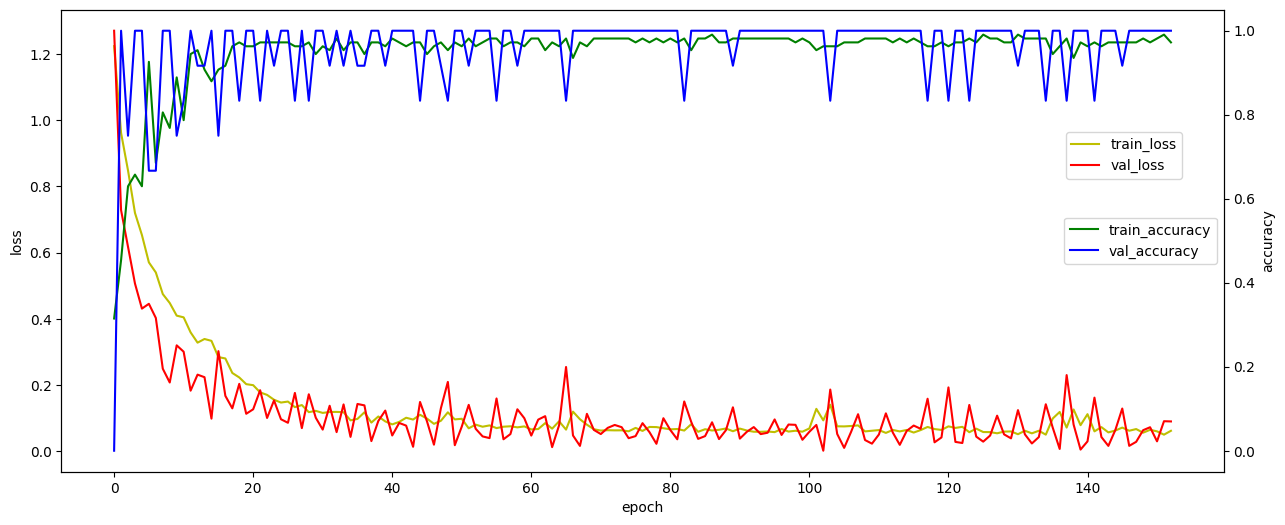

In [10]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [11]:
# 모델 평가
loss, acc = model.evaluate(test_X, test_y)
print(loss, acc)

1/1 [==============================] - 0s 31ms/step - loss: 0.0247 - accuracy: 1.0000
0.02468007057905197 1.0


In [13]:
# 저장된 모델중 최선 모델
model1 = load_model('model/iris-103-loss0.0016-acc1.0000.h5')
loss1, acc1 = model1.evaluate(test_X, test_y)
print(loss1, acc1)

1/1 [==============================] - 0s 177ms/step - loss: 0.2068 - accuracy: 0.9333
0.2068471908569336 0.9333333373069763


# 2. sklearn이용
- 4->64->128->50->30->3

In [14]:
from sklearn.neural_network import MLPClassifier  # multi-layer perceptron
# 1. 데이터
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((120, 4), (120,), (30, 4), (30,))

In [15]:
# 2. 모델 생성
model = MLPClassifier(hidden_layer_sizes=(64, 128, 50, 30),
                     activation='relu',
                     solver='adam', # 옵티마이저
                     batch_size=40, # 학습시 batch_size
                     early_stopping=True, # 조기 종료 활성화,
                     n_iter_no_change=50, # earlystopping의 patience역할
                     validation_fraction=0.1, # 검증셋 비율
                     max_iter=200, 
                     warm_start=False, # True일 경우 이전학습에 이어서 학습
                     )

In [16]:
# 3. 모델 학습
model.fit(train_X, train_y)

MLPClassifier(batch_size=40, early_stopping=True,
              hidden_layer_sizes=(64, 128, 50, 30), n_iter_no_change=50)

In [17]:
# 4. 모델 평가
model.score(test_X, test_y)

0.9666666666666667

In [18]:
# 5. 교차표(혼동행렬)
# 실제값 : test_y
y_hat = model.predict(test_X)
pd.crosstab(test_y, y_hat, rownames=['real'], colnames=['predict'])

predict,0,1,2
real,,,
0,10,0,0
1,0,9,1
2,0,0,10


In [19]:
from sklearn.metrics import confusion_matrix
confusion_matrix(test_y, y_hat)

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  0, 10]], dtype=int64)

# 3. 클래스를 생성하여 모델 생성함수 사용

In [20]:
class DNNClassifier:
    @staticmethod
    def build(input_dim=4, activation='relu', output_dim=3, optimizer='adam'):
        # 모델 구성
        model = Sequential(layers=[
            Input(input_dim),
            Dense(units=50, activation=activation),
            Dense(units=30, activation=activation),
            Dense(units=output_dim, activation='softmax')
        ], name='sequential')
        # 모델 학습 설정
        model.compile(loss='sparse_categorical_crossentropy',
                     optimizer=optimizer,
                     metrics=['accuracy'])
        # 모델 return
        return model

In [21]:
%%time
# 1. 데이터
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)
# 2. 모델
model = DNNClassifier.build(input_dim=4, activation='relu', output_dim=3, optimizer='adam')
# 3. 모델 학습
hist = model.fit(train_X, train_y,
                epochs=50, 
                validation_split=0.1, 
                verbose=0)

(120, 4) (120,) (30, 4) (30,)
CPU times: total: 3.48 s
Wall time: 3.16 s


In [22]:
# 모델 평가
loss, accuracy = model.evaluate(test_X, test_y, verbose=0)
print(f'정확도 : {accuracy*100}%')

정확도 : 100.0%


# 4. 함수형 API
- 병렬처리, Residual block

In [23]:
# 기존 model 스타일1
model = Sequential(layers=[
    Input(shape=(4,)),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax'),
])
# 기존 model 스타일2
model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=3, activation='softmax'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_11 (Dense)            (None, 50)                250       
                                                                 
 dense_12 (Dense)            (None, 30)                1530      
                                                                 
 dense_13 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [24]:
# 함수형 API 스타일
from tensorflow.keras import Model
input_ = Input(shape=(4,))
layer1 = Dense(units=50, activation='relu')(input_)
layer2 = Dense(units=30, activation='relu')(layer1)
output = Dense(units=3, activation='softmax')(layer2)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 4)]               0         
                                                                 
 dense_14 (Dense)            (None, 50)                250       
                                                                 
 dense_15 (Dense)            (None, 30)                1530      
                                                                 
 dense_16 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [25]:
# 4->160->3
# 기존의 model 방식
model = Sequential([
    Input(shape=(4,)),
    Dense(units=160, activation='relu'),
    Dense(units=3, activation='softmax')
])
# 함수형 API 방식
input_ = Input(shape=(4,))
layer  = Dense(units=160, activation='relu')(input_)
output = Dense(units=3,   activation='softmax')(layer)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 4)]               0         
                                                                 
 dense_19 (Dense)            (None, 160)               800       
                                                                 
 dense_20 (Dense)            (None, 3)                 483       
                                                                 
Total params: 1,283
Trainable params: 1,283
Non-trainable params: 0
_________________________________________________________________


In [26]:
# 4->160->3를 병렬처리 방식
from tensorflow.keras.layers import concatenate
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=80, activation='relu')(input_)
dense3 = Dense(units=30, activation='relu')(input_)
x      = concatenate([dense1, dense2, dense3])
output = Dense(units=3, activation='softmax')(x)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 4)]          0           []                               
                                                                                                  
 dense_21 (Dense)               (None, 50)           250         ['input_8[0][0]']                
                                                                                                  
 dense_22 (Dense)               (None, 80)           400         ['input_8[0][0]']                
                                                                                                  
 dense_23 (Dense)               (None, 30)           150         ['input_8[0][0]']                
                                                                                            

In [27]:
# 레지듀얼 블럭(Residual Block)
from tensorflow.keras.layers import add
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
layer1 = Dense(units=64, activation='relu')(dense1)
layer2 = Dense(units=50, activation='relu')(layer1)
dense2 = add([dense1, layer2])
output = Dense(units=3, activation='softmax')(dense2)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_9 (InputLayer)           [(None, 4)]          0           []                               
                                                                                                  
 dense_25 (Dense)               (None, 50)           250         ['input_9[0][0]']                
                                                                                                  
 dense_26 (Dense)               (None, 64)           3264        ['dense_25[0][0]']               
                                                                                                  
 dense_27 (Dense)               (None, 50)           3250        ['dense_26[0][0]']               
                                                                                            